# Tension Board 2 Mirror: Feature Engineering

The goal of this notebook is to convert raw climb descriptions into a clean modelling table. Each row of the final table corresponds to a single climb-angle observation, and each column is a numeric feature that may help predict grade.

## Modelling idea

A climb's grade should depend on more than just angle. It should also depend on the geometry and sequencing of the holds used. To capture that, this notebook builds features from three sources:

1. **Wall configuration**  
   Examples: angle, board geometry, mirrored placements.

2. **Route structure**  
   Examples: number of holds, spatial spread, height gained, move lengths, left/right balance, and other frame-derived quantities.

When this was initially done, we added:

3. **Hold difficulty priors** 

However, that makes it quite circular -- we'd be using the difficulty data to create difficulty scores to then predict difficulty data. The difficulty is already baked in there, so it is not a very good independent model. Heuristically, I don't think this is a big deal if we **just** want to predict V-grades, but we'll leave it out of our analysis in order to see what sorts of features actually help determine the difficulty of a climb. We'll add it back in notebook 07 and create a *leaky model*. 

## Output

The final product is a saved feature matrix that is reused in the predictive modelling and deep learning notebooks.

## Notebook Structure

1. [Setup and Imports](#setup-and-imports)
2. [Feature Extraction](#feature-extraction)
3. [Visualizing Key Features](#visualizing-key-features)
4. [Conclusion](#conclusion)

# Setup and Imports

This section loads the database, auxiliary tables, and the hold-difficulty table produced in notebook 03.


In [1]:
"""
==================================
Setup and Imports
==================================
"""

# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, squareform

import sqlite3

import re
import os
from collections import defaultdict

import ast

from PIL import Image

# Set some display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set style
palette=['steelblue', 'coral', 'seagreen']  #(for multi-bar graphs)

# Set board image for some visual analysis
board_img = Image.open('../images/tb2_board_12x12_composite.png')

# Connect to the database
DB_PATH="../data/tb2.db"
conn = sqlite3.connect(DB_PATH)

# Create output directories
os.makedirs('../data/04_climb_features', exist_ok=True)
os.makedirs('../images/04_climb_features', exist_ok=True)


In [2]:
"""
==================================
Query our data from the DB
==================================

This time we restrict to where `layout_id=10` for the TB2 Mirror.
We will also restrict ourselves to an angle of at most 50, since according to our grade vs angle distribution in notebook 01, things start to look a bit weird past 50.
(Probably a bias towards climbers who can actually climb that steep). We will encode this directly into our query.
"""

# Query climbs data
climbs_query = """
SELECT
    c.uuid,
    c.name AS climb_name,
    c.setter_username,
    c.layout_id AS layout_id,
    c.description,
    c.is_nomatch,
    c.is_listed,
    l.name AS layout_name,
    p.name AS board_name,
    c.frames,
    cs.angle,
    cs.display_difficulty,
    dg.boulder_name AS boulder_grade,
    cs.ascensionist_count,
    cs.quality_average,
    cs.fa_at
FROM climbs c
JOIN layouts l ON c.layout_id = l.id
JOIN products p ON l.product_id = p.id
JOIN climb_stats cs ON c.uuid = cs.climb_uuid
JOIN difficulty_grades dg ON ROUND(cs.display_difficulty) = dg.difficulty
WHERE cs.display_difficulty IS NOT NULL AND c.is_listed=1 AND c.layout_id=10 AND cs.angle <= 50
"""

# Query information about placements (and their mirrors)
placements_query = """
SELECT
    p.id AS placement_id,
    h.x,
    h.y,
    p.default_placement_role_id AS default_role_id,
    p.set_id AS set_id,
    s.name AS set_name,
    p_mirror.id AS mirror_placement_id
FROM placements p
JOIN holes h ON p.hole_id = h.id
JOIN sets s ON p.set_id = s.id
LEFT JOIN holes h_mirror ON h.mirrored_hole_id = h_mirror.id
LEFT JOIN placements p_mirror ON p_mirror.hole_id = h_mirror.id AND p_mirror.layout_id = p.layout_id
WHERE p.layout_id = 10
"""

# Load it into a DataFrame
df_climbs = pd.read_sql_query(climbs_query, conn)
df_placements = pd.read_sql_query(placements_query, conn)

# Load the hold-level difficulty table created in notebook 03
df_hold_difficulty = pd.read_csv('../data/03_hold_difficulty/hold_difficulty_scores.csv', index_col='placement_id')

In [3]:
print("Difficulty-related columns loaded from Notebook 03:")
print([c for c in df_hold_difficulty.columns if 'difficulty' in c.lower()])

assert 'overall_difficulty' in df_hold_difficulty.columns, "Missing overall_difficulty"

Difficulty-related columns loaded from Notebook 03:
['overall_difficulty_raw', 'overall_difficulty', 'angle_weighted_difficulty']


In [4]:
df_hold_difficulty

,x,y,material,default_role,overall_difficulty_raw,overall_difficulty,usage_count,climbs_count,angle_weighted_difficulty,angles_used,min_angle,max_angle,angle_range,start_diff_0deg,start_diff_5deg,start_diff_10deg,start_diff_15deg,start_diff_20deg,start_diff_25deg,start_diff_30deg,start_diff_35deg,start_diff_40deg,start_diff_45deg,start_diff_50deg,start_diff_55deg,start_diff_60deg,start_diff_65deg,start_overall_avg,start_total_uses,start_uses_0deg,start_uses_5deg,start_uses_10deg,start_uses_15deg,start_uses_20deg,start_uses_25deg,start_uses_30deg,start_uses_35deg,start_uses_40deg,start_uses_45deg,start_uses_50deg,start_uses_55deg,start_uses_60deg,start_uses_65deg,middle_diff_0deg,middle_diff_5deg,middle_diff_10deg,middle_diff_15deg,middle_diff_20deg,middle_diff_25deg,middle_diff_30deg,middle_diff_35deg,middle_diff_40deg,middle_diff_45deg,middle_diff_50deg,middle_diff_55deg,middle_diff_60deg,middle_diff_65deg,middle_overall_avg,middle_total_uses,middle_uses_0deg,middle_uses_5deg,middle_uses_10deg,middle_uses_15deg,middle_uses_20deg,middle_uses_25deg,middle_uses_30deg,middle_uses_35deg,middle_uses_40deg,middle_uses_45deg,middle_uses_50deg,middle_uses_55deg,middle_uses_60deg,middle_uses_65deg,finish_diff_0deg,finish_diff_5deg,finish_diff_10deg,finish_diff_15deg,finish_diff_20deg,finish_diff_25deg,finish_diff_30deg,finish_diff_35deg,finish_diff_40deg,finish_diff_45deg,finish_diff_50deg,finish_diff_55deg,finish_diff_60deg,finish_diff_65deg,finish_overall_avg,finish_total_uses,finish_uses_0deg,finish_uses_5deg,finish_uses_10deg,finish_uses_15deg,finish_uses_20deg,finish_uses_25deg,finish_uses_30deg,finish_uses_35deg,finish_uses_40deg,finish_uses_45deg,finish_uses_50deg,finish_uses_55deg,finish_uses_60deg,finish_uses_65deg,hand_diff_0deg,hand_diff_5deg,hand_diff_10deg,hand_diff_15deg,hand_diff_20deg,hand_diff_25deg,hand_diff_30deg,hand_diff_35deg,hand_diff_40deg,hand_diff_45deg,hand_diff_50deg,hand_diff_55deg,hand_diff_60deg,hand_diff_65deg,hand_overall_avg,hand_total_uses,hand_uses_0deg,hand_uses_5deg,hand_uses_10deg,hand_uses_15deg,hand_uses_20deg,hand_uses_25deg,hand_uses_30deg,hand_uses_35deg,hand_uses_40deg,hand_uses_45deg,hand_uses_50deg,hand_uses_55deg,hand_uses_60deg,hand_uses_65deg,foot_diff_0deg,foot_diff_5deg,foot_diff_10deg,foot_diff_15deg,foot_diff_20deg,foot_diff_25deg,foot_diff_30deg,foot_diff_35deg,foot_diff_40deg,foot_diff_45deg,foot_diff_50deg,foot_diff_55deg,foot_diff_60deg,foot_diff_65deg,foot_overall_avg,foot_total_uses,foot_uses_0deg,foot_uses_5deg,foot_uses_10deg,foot_uses_15deg,foot_uses_20deg,foot_uses_25deg,foot_uses_30deg,foot_uses_35deg,foot_uses_40deg,foot_uses_45deg,foot_uses_50deg,foot_uses_55deg,foot_uses_60deg,foot_uses_65deg,diff_as_hand,uses_as_hand,diff_as_foot,uses_as_foot
placement_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
672,-64,4,Plastic,8,21.38,21.460,711,519,21.326090,13,0,65,65,19.132030,NaN,NaN,NaN,19.322506,NaN,19.370125,NaN,19.642288,NaN,NaN,NaN,NaN,NaN,19.370,5.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.334411,NaN,NaN,NaN,NaN,NaN,19.330,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.132030,NaN,NaN,NaN,19.322506,NaN,19.370125,NaN,19.442231,NaN,NaN,NaN,NaN,NaN,19.350,6,1,0,0,0,1,0,0,0,4,0,0,0,0,0,19.112419,18.580574,18.951265,18.320443,17.948354,18.688513,19.835855,19.886668,22.218812,22.701984,22.305111,20.611099,19.759982,19.571483,19.955,705.0,3.0,0.0,5.0,15.0,40.0,35.0,82.0,41.0,334.0,119.0,23.0,5.0,1.0,2.0,19.15,6,21.35,705
673,-64,20,Plastic,8,21.80,21.530,368,260,21.296679,14,0,65,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.362796,19.465363,NaN,NaN,NaN,NaN,19.375,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [5]:
placement_coords = {
    row['placement_id']: (row['x'], row['y'])
    for _, row in df_placements.iterrows()
}

board_width = 144
board_height = 144

x_min, x_max = -68, 68
y_min, y_max = 0, 144

# Role definitions (TB2)
ROLE_DEFINITIONS = {
    'start': 5,
    'middle': 6,
    'finish': 7,
    'foot': 8
}

HAND_ROLE_IDS = [5, 6, 7]
FOOT_ROLE_IDS = [8]



In [6]:
"""
==================================
Parse Frame function
==================================
"""

def parse_frames(frames_str):
    """
    Parse frames string into list of (placement_id, role_id) tuples.
    
    Parameters:
    -----------
    frames_str : str
        Frame string like "p1r5p2r6p3r8"
    
    Returns:
    --------
    list of tuples: [(placement_id, role_id), ...]
    """
    if not isinstance(frames_str, str):
        return []
    
    matches = re.findall(r'p(\d+)r(\d+)', frames_str)
    return [(int(p), int(r)) for p, r in matches]


def get_role_type(role_id):
    """Map role_id to role type string."""
    for role_type, rid in ROLE_DEFINITIONS.items():
        if role_id == rid:
            return role_type
    return 'unknown'


# Test
test_frames = "p1r5p2r6p3r8p4r5"
parsed = parse_frames(test_frames)
print(f"Test parse: {parsed}")

Test parse: [(1, 5), (2, 6), (3, 8), (4, 5)]


# Feature Extraction

This is the core notebook section. The aim is to translate the raw `frames` string into a route-level numerical representation suitable for regression or classification models.


In [7]:
"""
==================================
Feature Exraction Function
==================================
"""

'\n==================================\nFeature Exraction Function\n==================================\n'

In [8]:
def extract_features(row, placement_coords):
    """
    Extract a trimmed set of clean geometric/spatial features.
    No hold-difficulty-derived features are used.
    """
    features = {}

    holds = parse_frames(row['frames'])
    angle = row['angle']

    if not holds:
        return None

    hold_data = []
    for placement_id, role_id in holds:
        coords = placement_coords.get(placement_id, (None, None))
        if coords[0] is None:
            continue

        role_type = get_role_type(role_id)
        is_hand = role_id in HAND_ROLE_IDS
        is_foot = role_id in FOOT_ROLE_IDS

        hold_data.append({
            'placement_id': placement_id,
            'x': coords[0],
            'y': coords[1],
            'role_type': role_type,
            'is_hand': is_hand,
            'is_foot': is_foot,
        })

    if not hold_data:
        return None

    df_holds = pd.DataFrame(hold_data)

    hand_holds = df_holds[df_holds['is_hand']]
    foot_holds = df_holds[df_holds['is_foot']]
    start_holds = df_holds[df_holds['role_type'] == 'start']
    finish_holds = df_holds[df_holds['role_type'] == 'finish']
    middle_holds = df_holds[df_holds['role_type'] == 'middle']

    xs = df_holds['x'].to_numpy()
    ys = df_holds['y'].to_numpy()

    description = row.get('description', '')
    if pd.isna(description):
        description = ''

    center_x = (x_min + x_max) / 2

    # Basic
    features['angle'] = angle
    features['angle_squared'] = angle ** 2

    features['total_holds'] = len(df_holds)
    features['hand_holds'] = len(hand_holds)
    features['foot_holds'] = len(foot_holds)
    features['start_holds'] = len(start_holds)
    features['finish_holds'] = len(finish_holds)
    features['middle_holds'] = len(middle_holds)

    features['is_nomatch'] = int(
        (row['is_nomatch'] == 1) or
        bool(re.search(r'\bno\s*match(ing)?\b', description, flags=re.IGNORECASE))
    )

    # Spatial
    features['mean_y'] = np.mean(ys)
    features['std_x'] = np.std(xs) if len(xs) > 1 else 0.0
    features['std_y'] = np.std(ys) if len(ys) > 1 else 0.0
    features['range_x'] = np.max(xs) - np.min(xs)
    features['range_y'] = np.max(ys) - np.min(ys)
    features['min_y'] = np.min(ys)
    features['max_y'] = np.max(ys)
    features['height_gained'] = features['max_y'] - features['min_y']

    # Start / finish heights
    start_height = start_holds['y'].mean() if len(start_holds) > 0 else np.nan
    finish_height = finish_holds['y'].mean() if len(finish_holds) > 0 else np.nan

    features['height_gained_start_finish'] = (
        finish_height - start_height
        if pd.notna(start_height) and pd.notna(finish_height)
        else np.nan
    )

    # Density / symmetry
    bbox_area = features['range_x'] * features['range_y']
    features['bbox_area'] = bbox_area
    features['hold_density'] = features['total_holds'] / bbox_area if bbox_area > 0 else 0.0
    features['holds_per_vertical_foot'] = features['total_holds'] / max(features['range_y'], 1)

    left_holds = (df_holds['x'] < center_x).sum()
    features['left_ratio'] = left_holds / features['total_holds'] if features['total_holds'] > 0 else 0.5
    features['symmetry_score'] = 1 - abs(features['left_ratio'] - 0.5) * 2

    y_median = np.median(ys)
    upper_holds = (df_holds['y'] > y_median).sum()
    features['upper_ratio'] = upper_holds / features['total_holds']

    # Hand reach
    if len(hand_holds) >= 2:
        hand_points = hand_holds[['x', 'y']].to_numpy()
        hand_distances = pdist(hand_points)

        hand_xs = hand_holds['x'].to_numpy()
        hand_ys = hand_holds['y'].to_numpy()

        features['mean_hand_reach'] = float(np.mean(hand_distances))
        features['max_hand_reach'] = float(np.max(hand_distances))
        features['std_hand_reach'] = float(np.std(hand_distances))
        features['hand_spread_x'] = float(hand_xs.max() - hand_xs.min())
        features['hand_spread_y'] = float(hand_ys.max() - hand_ys.min())
    else:
        features['mean_hand_reach'] = 0.0
        features['max_hand_reach'] = 0.0
        features['std_hand_reach'] = 0.0
        features['hand_spread_x'] = 0.0
        features['hand_spread_y'] = 0.0

    # Hand-foot distances
    if len(hand_holds) > 0 and len(foot_holds) > 0:
        hand_points = hand_holds[['x', 'y']].to_numpy()
        foot_points = foot_holds[['x', 'y']].to_numpy()

        dists = []
        for hx, hy in hand_points:
            for fx, fy in foot_points:
                dists.append(np.sqrt((hx - fx)**2 + (hy - fy)**2))
        dists = np.asarray(dists)

        features['min_hand_to_foot'] = float(np.min(dists))
        features['mean_hand_to_foot'] = float(np.mean(dists))
        features['std_hand_to_foot'] = float(np.std(dists))
    else:
        features['min_hand_to_foot'] = 0.0
        features['mean_hand_to_foot'] = 0.0
        features['std_hand_to_foot'] = 0.0

    # Global geometry
    points = np.column_stack([xs, ys])

    if len(df_holds) >= 3:
        try:
            hull = ConvexHull(points)
            features['convex_hull_area'] = float(hull.volume)
            features['hull_area_to_bbox_ratio'] = features['convex_hull_area'] / max(bbox_area, 1)
        except Exception:
            features['convex_hull_area'] = np.nan
            features['hull_area_to_bbox_ratio'] = np.nan
    else:
        features['convex_hull_area'] = 0.0
        features['hull_area_to_bbox_ratio'] = 0.0

    if len(df_holds) >= 2:
        pairwise = pdist(points)
        features['mean_pairwise_distance'] = float(np.mean(pairwise))
        features['std_pairwise_distance'] = float(np.std(pairwise))
    else:
        features['mean_pairwise_distance'] = 0.0
        features['std_pairwise_distance'] = 0.0

    if len(df_holds) >= 2:
        sorted_idx = np.argsort(ys)
        sorted_points = points[sorted_idx]

        path_length = 0.0
        for i in range(len(sorted_points) - 1):
            dx = sorted_points[i + 1, 0] - sorted_points[i, 0]
            dy = sorted_points[i + 1, 1] - sorted_points[i, 1]
            path_length += np.sqrt(dx**2 + dy**2)

        features['path_length_vertical'] = path_length
        features['path_efficiency'] = features['height_gained'] / max(path_length, 1)
    else:
        features['path_length_vertical'] = 0.0
        features['path_efficiency'] = 0.0

    # Normalized / relative
    features['mean_y_normalized'] = (features['mean_y'] - y_min) / board_height
    features['start_height_normalized'] = (
        (start_height - y_min) / board_height if pd.notna(start_height) else np.nan
    )
    features['finish_height_normalized'] = (
        (finish_height - y_min) / board_height if pd.notna(finish_height) else np.nan
    )
    features['mean_y_relative_to_start'] = (
        features['mean_y'] - start_height if pd.notna(start_height) else np.nan
    )
    features['spread_x_normalized'] = features['range_x'] / board_width
    features['spread_y_normalized'] = features['range_y'] / board_height

    y_q75 = np.percentile(ys, 75)
    y_q25 = np.percentile(ys, 25)
    features['y_q75'] = y_q75
    features['y_iqr'] = y_q75 - y_q25

    # Optional engineered clean feature
    features['complexity_score'] = (
        features['mean_hand_reach']
        * np.log1p(features['total_holds'])
        * (1 + features['hold_density'])
    )

    return features

## Sanity Check on One Example

Before extracting features for the entire dataset, we inspect one representative climb to confirm that the parsing logic and the computed geometric summaries behave as expected. Let's do the climb "Ooo La La" from notebook two.

![Ooo La La](../images/02_hold_stats/Ooo_La_La.png)


In [9]:
extract_features(df_climbs.iloc[10000], placement_coords)

{'angle': np.int64(25),
 'angle_squared': np.int64(625),
 'total_holds': 9,
 'hand_holds': 6,
 'foot_holds': 3,
 'start_holds': 2,
 'finish_holds': 1,
 'middle_holds': 3,
 'is_nomatch': 1,
 'mean_y': np.float64(70.22222222222223),
 'std_x': np.float64(11.313708498984761),
 'std_y': np.float64(26.20338306308209),
 'range_x': np.int64(32),
 'range_y': np.int64(80),
 'min_y': np.int64(36),
 'max_y': np.int64(116),
 'height_gained': np.int64(80),
 'height_gained_start_finish': np.float64(58.0),
 'bbox_area': np.int64(2560),
 'hold_density': np.float64(0.003515625),
 'holds_per_vertical_foot': np.float64(0.1125),
 'left_ratio': np.float64(0.0),
 'symmetry_score': np.float64(0.0),
 'upper_ratio': np.float64(0.4444444444444444),
 'mean_hand_reach': 33.51231456475284,
 'max_hand_reach': 66.2117814289874,
 'std_hand_reach': 17.192772876407144,
 'hand_spread_x': 32.0,
 'hand_spread_y': 60.0,
 'min_hand_to_foot': 16.0,
 'mean_hand_to_foot': 44.198884621702035,
 'std_hand_to_foot': 20.661632138868

The printed example above is an important checkpoint. If the parsed placements, role counts, or geometric summaries look unreasonable here, then the full feature matrix will inherit those mistakes.


## Extract Features or all climbs

In [10]:
"""
==================================
Extract features for all climbs
==================================
"""

from tqdm import tqdm # Progess bar. This will take a while.

print(f"Extracting features for {len(df_climbs)} climbs...")

feature_list = []

for idx, row in tqdm(df_climbs.iterrows(), total=len(df_climbs)):
    features = extract_features(row, placement_coords)
    if features:
        features['climb_uuid'] = row['uuid']
        features['display_difficulty'] = row['display_difficulty']
        feature_list.append(features)

df_features = pd.DataFrame(feature_list)
df_features = df_features.set_index('climb_uuid')

print(f"\nExtracted features for {len(df_features)} climbs")
print(f"Feature columns: {len(df_features.columns)}")

print("\n### Feature Table Sample\n")
display(df_features.head(10))

Extracting features for 42596 climbs...


100%|██████████| 42596/42596 [04:19<00:00, 163.84it/s]



Extracted features for 42596 climbs
Feature columns: 48

### Feature Table Sample



,angle,angle_squared,total_holds,hand_holds,foot_holds,start_holds,finish_holds,middle_holds,is_nomatch,mean_y,std_x,std_y,range_x,range_y,min_y,max_y,height_gained,height_gained_start_finish,bbox_area,hold_density,holds_per_vertical_foot,left_ratio,symmetry_score,upper_ratio,mean_hand_reach,max_hand_reach,std_hand_reach,hand_spread_x,hand_spread_y,min_hand_to_foot,mean_hand_to_foot,std_hand_to_foot,convex_hull_area,hull_area_to_bbox_ratio,mean_pairwise_distance,std_pairwise_distance,path_length_vertical,path_efficiency,mean_y_normalized,start_height_normalized,finish_height_normalized,mean_y_relative_to_start,spread_x_normalized,spread_y_normalized,y_q75,y_iqr,complexity_score,display_difficulty
climb_uuid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0A70BF5C001641D3BBE59E11528A7251,20,400,12,8,4,1,1,6,1,73.0,7.564537,42.868014,24,136,4,140,136,96.0,3264,0.003676,0.088235,0.000000,0.000000,0.5,43.264303,96.332757,23.229908,16.0,96.0,11.313708,69.725793,34.932990,2304.0,0.705882,55.633416,32.237030,201.915033,0.673551,0.506944,0.305556,0.972222,29.0,0.166667,0.944444,107.0,67.0,111.378728,11.0000
0A70BF5C001641D3BBE59E11528A7251,25,625,12,8,4,1,1,6,1,73.0,7.564537,42.868014,24,136,4,140,136,96.0,3264,0.003676,0.088235,0.000000,0.000000,0.5,43.264303,96.332757,23.229908,16.0,96.0,11.313708,69.725793,34.932990,2304.0,0.705882,55.633416,32.237030,201.915033,0.673551,0.506944,0.305556,0.972222,29.0,0.166667,0.944444,107.0,67.0,111.378728,13.1429
0A70BF5C001641D3BBE59E11528A7251,30,900,12,8,4,1,1,6,1,73.0,7.564537,42.868014,24,136,4,140,136,96.0,3264,0.003676,0.088235,0.000000,0.000000,0.5,43.264303,96.332757,23.229908,16.0,96.0,11.313708,69.725793,34.932990,2304.0,0.705882,55.633416,32.237030,201.915033,0.673551,0.506944,0.305556,0.972222,29.0,0.166667,0.944444,107.0,67.0,111.378728,10.6667
0A70BF5C001641D3BBE59E11528A7251,35,1225,12,8,4,1,1,6,1,73.0,7.564537,42.868014,24,136,4,140,136,96.0,3264,0.003676,0.088235,0.000000,0.000000,0.5,43.264303,96.332757,23.229908,16.0,96.0,11.313708,69.725793,34.932990,2304.0,0.705882,55.633416,32.237030,201.915033,0.673551,0.506944,0.305556,0.972222,29.0,0.166667,0.944444,107.0,67.0,111.378728,12.4286
0A70BF5C001641D3BBE59E11528A7251,40,1600,12,8,4,1,1,6,1,73.0,7.564537,42.868014,24,136,4,140,136,96.0,3264,0.003676,0.088235,0.000000,0.000000,0.5,43.264303,96.332757,23.229908,16.0,96.0,11.313708,69.725793,34.932990,2304.0,0.705882,55.633416,32.237030,201.915033,0.673551,0.506944,0.305556,0.972222,29.0,0.166667,0.944444,107.0,67.0,111.378728,13.7857
0DEA33F171FE4DEF85A5E284758A9040,10,100,14,8,6,1,1,6,1,68.0,22.366155,41.126981,80,136,4,140,136,96.0,10880,0.001287,0.102941,0.071429,0.142857,0.5,49.971785,111.139552,27.978934,56.0,96.0,28.284271,68.482880,32.874943,4992.0,0.458824,60.892840,31.821211,421.002757,0.323038,0.472222,0.305556,0.972222,24.0,0.555556,0.944444,93.0,49.0,135.500234,12.0000
0DEA33F171FE4DEF85A5E284758A9040,15,225,14,8,6,1,1,6,1,68.0,22.366155,41.126981,80,136,4,140,136,96.0,10880,0.001287,0.102941,0.071429,0.142857,0.5,49.971785,111.139552,27.978934,56.0,96.0,28.284271,68.482880,32.874943,4992.0,0.458824,60.892840,31.821211,421.002757,0.323038,0.472222,0.305556,0.972222,24.0,0.555556,0.944444,93.0,49.0,135.500234,13.0000
0DEA33F171FE4DEF85A5E284758A9040,20,400,14,8,6,1,1,6,1,68.0,22.366155,41.126981,80,136,4,140,136,96.0,10880,0.001287,0.102941,0.071429,0.142857,0.5,49.971785,111.139552,27.978934,56.0,96.0,28.284271,68.482880,32.874943,4992.0,0.458824,60.892840,31.821211,421.002757,0.323038,0.472222,0.305556,0.972222,24.0,0.555556,0.944444,93.0,49.0,135.500234,12.8571
0DEA33F171FE4DEF85A5E284758A9040,25,625,14,8,6,1,1,6,1,68.0,22.366155,41.126981,80,136,4,140,136,96.0,10880,0.001287,0.102941,0.071429,0.142857,0.5,49.971785,111.139552,27.978934,56.0,96.0,28.284271,68.482880,32.874943,4992.0,0.458824,60.892840,31.821211,421.002757,0.323038,0.472222,0.305556,0.972222,24.0,0.555556,0.944444,93.0,49.0,135.500234,12.8889


In [11]:
"""
==================================
Feature Summary Statistics
==================================
"""

print("### Feature Summary\n")

summary = df_features.describe().T
summary['missing'] = df_features.isna().sum()
summary['missing_pct'] = (df_features.isna().sum() / len(df_features) * 100).round(2)

display(summary[['count', 'mean', 'std', 'min', 'max', 'missing', 'missing_pct']])

### Feature Summary



,count,mean,std,min,max,missing,missing_pct
angle,42596.0,36.753216,9.084737,0.000000,50.000000,0,0.00
angle_squared,42596.0,1433.329421,571.104081,0.000000,2500.000000,0,0.00
total_holds,42596.0,10.940464,4.788640,2.000000,147.000000,0,0.00
hand_holds,42596.0,7.367617,2.748163,2.000000,83.000000,0,0.00
foot_holds,42596.0,3.572847,2.572115,0.000000,64.000000,0,0.00
start_holds,42596.0,1.535614,0.498736,1.000000,2.000000,0,0.00
finish_holds,42596.0,1.067213,0.250393,1.000000,2.000000,0,0.00
middle_holds,42596.0,4.764790,2.718850,0.000000,81.000000,0,0.00
is_nomatch,42596.0,0.521528,0.499542,0.000000,1.000000,0,0.00
mean_y,42596.0,72.196213,10.696898,20.761905,134.000000,0,0.00


## Correlation with Difficulty

In [12]:
"""
==================================
Correlation with Difficulty
==================================
"""

correlations = df_features.corr()['display_difficulty'].drop('display_difficulty').sort_values(key=abs, ascending=False)

print("### Top 30 Features Correlated with Difficulty\n")
display(correlations.head(30).to_frame('correlation'))

print("\n### Bottom 10 Features (Least Correlated)\n")
display(correlations.tail(10).to_frame('correlation'))

### Top 30 Features Correlated with Difficulty



,correlation
mean_hand_reach,0.542550
angle,0.426380
angle_squared,0.405046
mean_pairwise_distance,0.397894
hold_density,-0.389647
std_hand_reach,0.365282
max_hand_reach,0.365259
std_x,0.362368
hand_spread_x,0.327927
bbox_area,0.324689



### Bottom 10 Features (Least Correlated)



,correlation
start_height_normalized,-0.087389
path_length_vertical,-0.067043
spread_y_normalized,0.064610
range_y,0.064610
height_gained,0.064610
y_iqr,0.059431
path_efficiency,0.040048
upper_ratio,-0.039220
start_holds,0.024975
left_ratio,0.022934


# Visualizing Key Features

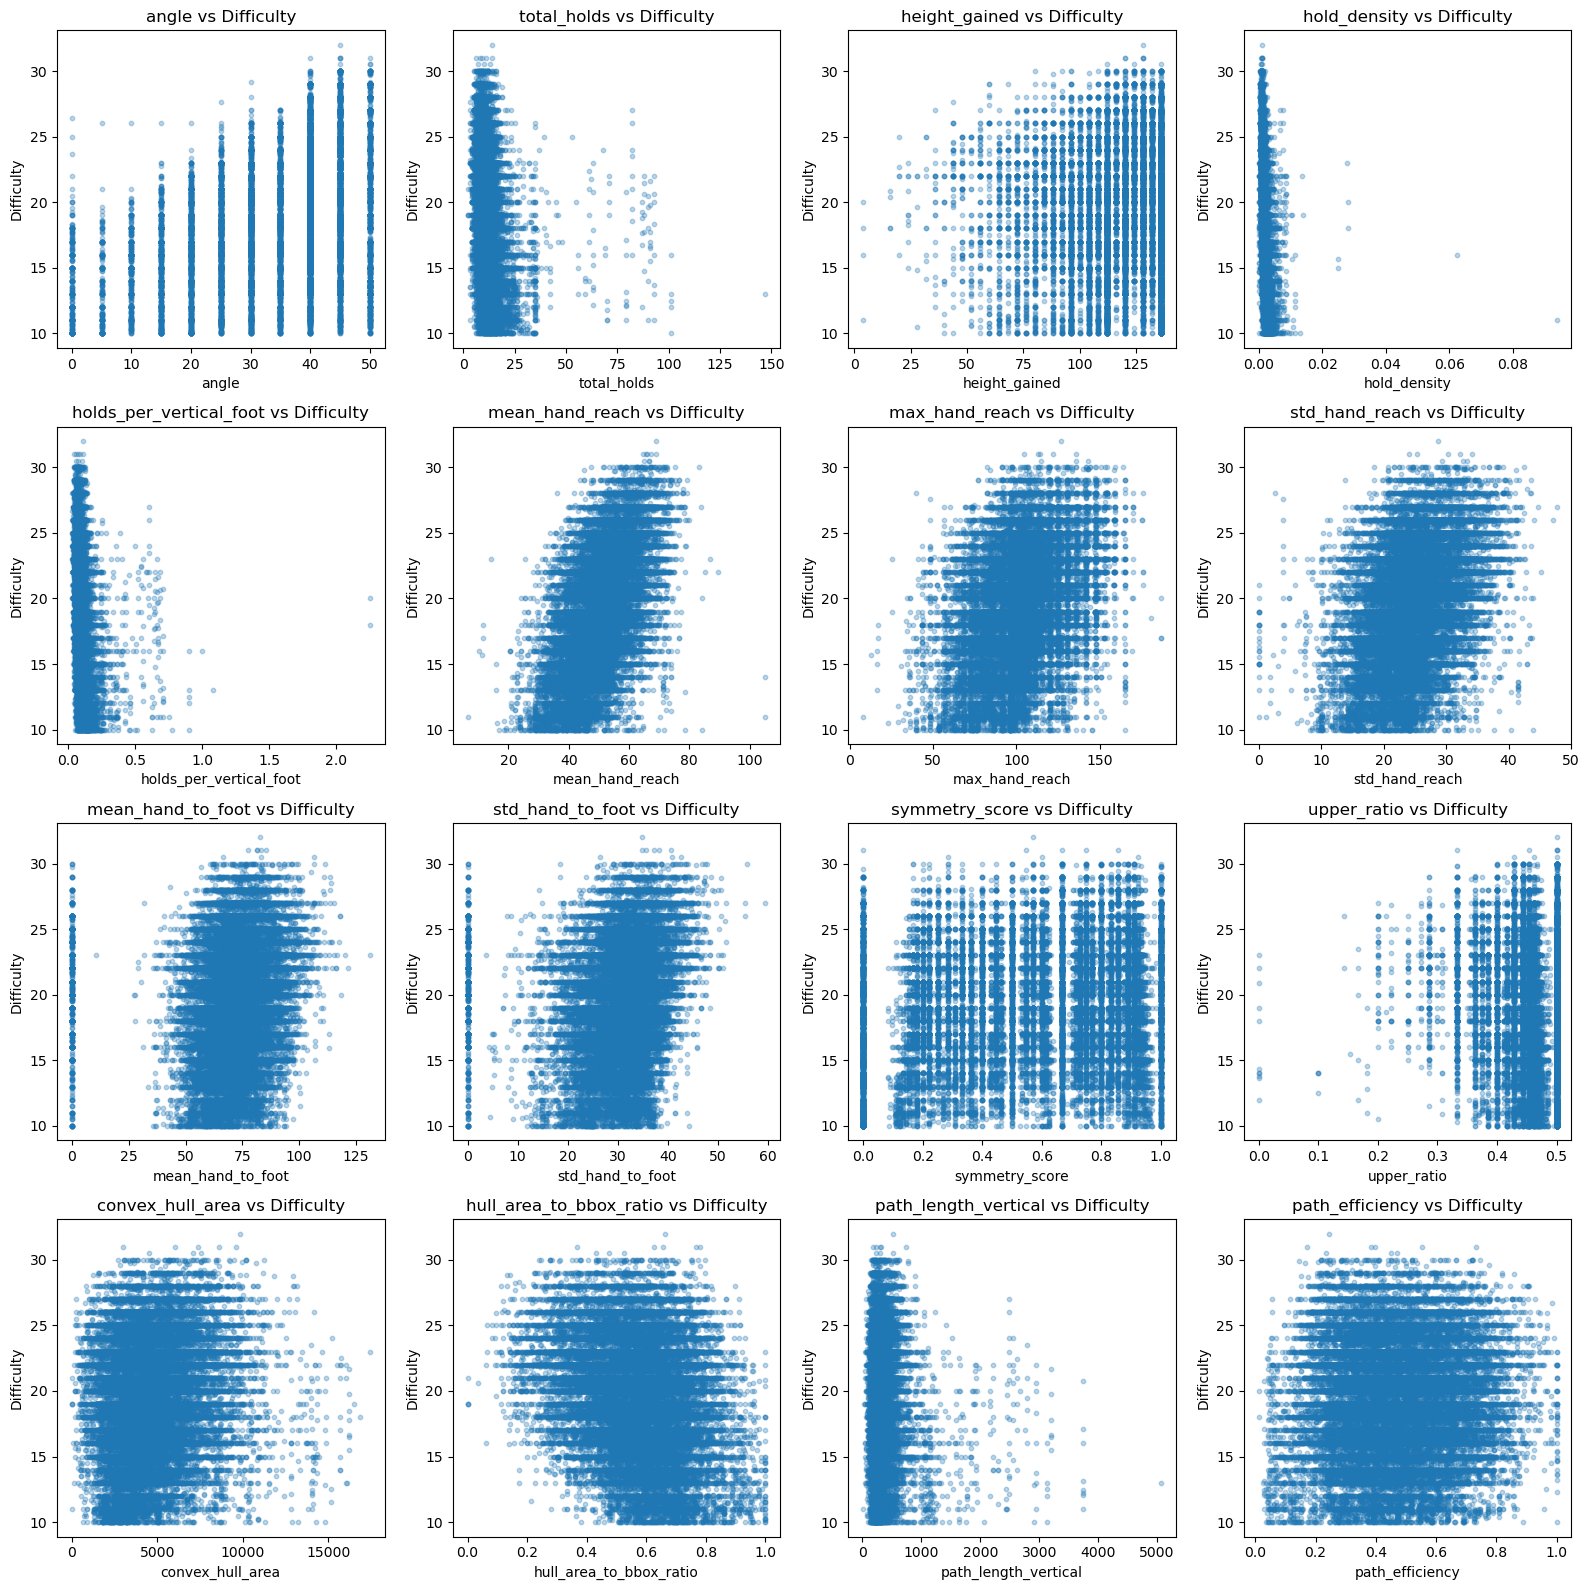

In [13]:
"""
==================================
Visualize Key Features
==================================
"""

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

key_features = [
    # Core driver
    'angle',

    # Basic structure
    'total_holds',
    'height_gained',

    # Density / compactness
    'hold_density',
    'holds_per_vertical_foot',

    # Hand geometry (very important)
    'mean_hand_reach',
    'max_hand_reach',
    'std_hand_reach',

    # Hand-foot interaction
    'mean_hand_to_foot',
    'std_hand_to_foot',

    # Spatial layout
    'symmetry_score',
    'upper_ratio',

    # Global geometry
    'convex_hull_area',
    'hull_area_to_bbox_ratio',

    # Path / flow
    'path_length_vertical',
    'path_efficiency'
]

for ax, feature in zip(axes.flat, key_features):
    if feature in df_features.columns:
        ax.scatter(df_features[feature], df_features['display_difficulty'], alpha=0.3, s=10)
        ax.set_xlabel(feature)
        ax.set_ylabel('Difficulty')
        ax.set_title(f'{feature} vs Difficulty')

plt.tight_layout()
plt.savefig('../images/04_climb_features/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
"""
==================================
Add Interaction Features
==================================
"""

# Angle interactions
df_features['angle_x_holds'] = df_features['angle'] * df_features['total_holds']
df_features['angle_squared'] = df_features['angle'] ** 2


# Complexity features
df_features['complexity_score'] = (
    df_features['total_holds'] * 
    df_features['mean_hand_reach'].fillna(0) * 
    df_features['hold_density']
)

print(f"Added interaction features. Total columns: {len(df_features.columns)}")

Added interaction features. Total columns: 49


In [18]:
"""
==================================
Handle Missing Values
==================================
"""

missing = df_features.isna().sum()
missing_cols = missing[missing > 0]

print("### Columns with Missing Values\n")
display(missing_cols.to_frame('missing'))


# Fill other NaNs with column means
for col in df_features.columns:
    if df_features[col].isna().any():
        if df_features[col].dtype in ['float64', 'int64']:
            df_features[col] = df_features[col].fillna(df_features[col].mean())

# Check remaining missing
remaining = df_features.isna().sum().sum()
print(f"\nRemaining missing values: {remaining}")

### Columns with Missing Values



,missing
convex_hull_area,50
hull_area_to_bbox_ratio,50



Remaining missing values: 0


In [19]:
"""
===================================
Feature Importance Review
===================================
"""

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

X = df_features.drop(columns=['display_difficulty'])
y = df_features['display_difficulty']

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=3, n_jobs=-1)
rf.fit(X, y)

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("### Top 30 Most Important Features (Random Forest)\n")
display(importance.head(30))

# Cross-validation score
scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error')
print(f"\nCross-validated MAE: {-scores.mean():.2f} (+/- {scores.std():.2f})")

### Top 30 Most Important Features (Random Forest)



,feature,importance
19,hold_density,0.391769
24,mean_hand_reach,0.155421
1,angle_squared,0.113509
0,angle,0.099099
14,min_y,0.031800
46,complexity_score,0.016717
26,std_hand_reach,0.012847
39,start_height_normalized,0.011011
41,mean_y_relative_to_start,0.009757
33,hull_area_to_bbox_ratio,0.007488



Cross-validated MAE: 2.21 (+/- 0.17)


# Conclusion

In [20]:
"""
============================
Save Feature Matrix
============================
"""
raw_cols = [c for c in df_features.columns if c.endswith('_raw')]
if raw_cols:
    print("Dropping raw columns from final climb feature matrix:")
    print(raw_cols)
    df_features = df_features.drop(columns=raw_cols)

# `climb_features.csv` is the canonical name used by later notebooks.
df_features.to_csv('../data/04_climb_features/climb_features.csv')

print("Saved feature matrix to:")
print("  - ../data/04_climb_features/climb_features.csv")

with open('../data/04_climb_features/feature_list.txt', 'w') as f:
    for col in df_features.columns:
        f.write(f"{col}\n")

print("\nFeature list saved to ../data/04_climb_features/feature_list.txt")


Saved feature matrix to:
  - ../data/04_climb_features/climb_features.csv

Feature list saved to ../data/04_climb_features/feature_list.txt


In [21]:
"""
==================================
Final Feature Summary
==================================
"""

print("### Feature Engineering Complete\n")
print(f"Total climbs: {len(df_features)}")
print(f"Total features: {df_features.shape[1] - 1}")  # Exclude target
print(f"Target: display_difficulty")
print(f"Feature matrix shape: {df_features.shape}")

print("""\nInterpretation:
- Each row is a climb-angle observation.
- The target is `display_difficulty`.
- The predictors combine geometry, hold statistics, and aggregate difficulty information.
- Hold-difficulty-based features use Bayesian-smoothed hold scores from Notebook 03.
- The next notebook tests how much predictive signal these engineered features actually contain.
""")


### Feature Engineering Complete

Total climbs: 42596
Total features: 48
Target: display_difficulty
Feature matrix shape: (42596, 49)

Interpretation:
- Each row is a climb-angle observation.
- The target is `display_difficulty`.
- The predictors combine geometry, hold statistics, and aggregate difficulty information.
- Hold-difficulty-based features use Bayesian-smoothed hold scores from Notebook 03.
- The next notebook tests how much predictive signal these engineered features actually contain.

